# **Comparison of Clustering Methods**

practical 5

Name :Prem Rai

rollno: ACE079BCT045

**1. Dataset Overview**

The dataset used in this project contains information about 1,000 customers. It includes demographic and behavioral information that can be used to identify different types of customers.

The dataset contains the following five variables:

Feature	Description
customer_id	Unique identification number for each customer
age	Age of the customer
income	Annual income of the customer
spending_score	Score representing the customer's spending behavior
visits_per_month	Average number of visits made by the customer each month

The dataset does not contain any missing values or duplicate records. Since customer_id is only used to identify customers and does not represent customer behavior, it is not included as a feature in the clustering models.

The features used for clustering are:

Age
Income
Spending Score
Visits per Month

These variables provide a combination of demographic and behavioral information that can help us understand different customer groups.

**2. Objectives**

The main objective of this project is to divide customers into meaningful groups based on their characteristics and behavior.

The specific objectives are:

To explore and understand the customer dataset.
To prepare and standardize the features for clustering.
To apply K-Means Clustering and identify suitable customer segments.
To apply Hierarchical Clustering and compare its results with K-Means.
To apply DBSCAN to identify customer groups and possible outliers.
To compare the three clustering methods using the Silhouette Score.
To identify which clustering method performs best for this dataset.
To understand the characteristics of the resulting customer segments and provide useful business insights.


**3. Clustering Methods**

In this project, three different clustering techniques are used:

K-Means Clustering

K-Means groups customers into a predefined number of clusters based on the similarity between their features. The Elbow Method and Silhouette Score are used to help select the number of clusters.

Hierarchical Clustering

Hierarchical Clustering creates a hierarchy of groups by progressively combining similar observations. A dendrogram is used to visualize how the customers are grouped together.

DBSCAN

DBSCAN is a density-based clustering method. Unlike K-Means and Hierarchical Clustering, it does not require the number of clusters to be specified beforehand. It can also identify observations that do not fit well into any group as noise or outliers.

**CODE**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("13_customer_segmentation.csv")

In [3]:
df.head()

,customer_id,age,income,spending_score,visits_per_month
0,CUST1000,56,120186,55,9
1,CUST1001,69,49674,80,1
2,CUST1002,46,61271,62,8
3,CUST1003,32,88688,30,6
4,CUST1004,60,126076,55,6


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customer_id       1000 non-null   object
 1   age               1000 non-null   int64 
 2   income            1000 non-null   int64 
 3   spending_score    1000 non-null   int64 
 4   visits_per_month  1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


In [5]:
df.isnull().sum()

customer_id         0
age                 0
income              0
spending_score      0
visits_per_month    0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [8]:
features = ['age', 'income', 'spending_score', 'visits_per_month']

X = df[features]

X.head()

,age,income,spending_score,visits_per_month
0,56,120186,55,9
1,69,49674,80,1
2,46,61271,62,8
3,32,88688,30,6
4,60,126076,55,6


In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

X_scaled_df.head()

,age,income,spending_score,visits_per_month
0,0.812959,0.922445,0.217386,-0.196191
1,1.680578,-0.872969,1.077435,-1.640097
2,0.145560,-0.577680,0.458200,-0.376679
3,-0.788799,0.120426,-0.642663,-0.737656
4,1.079919,1.072420,0.217386,-0.737656


# K means clustering

In [11]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

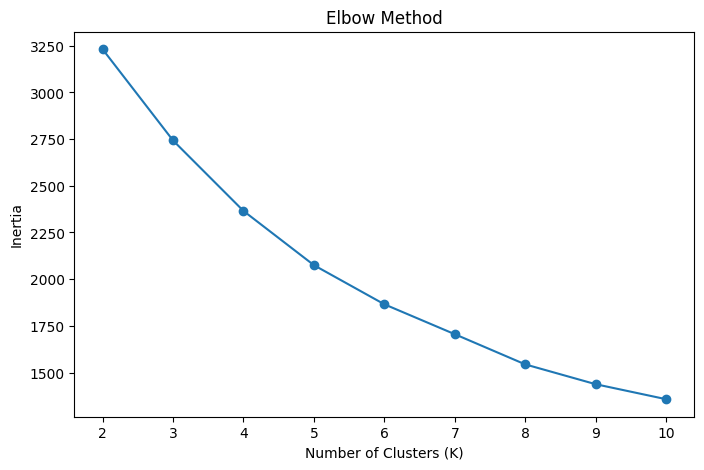

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

In [13]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

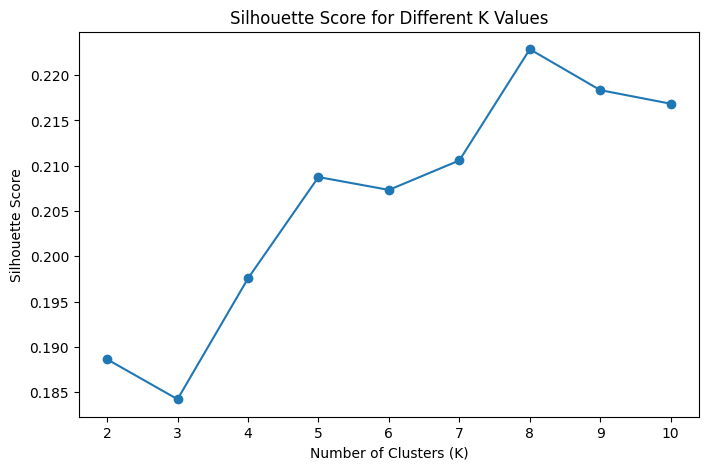

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')

plt.show()

In [15]:
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,customer_id,age,income,spending_score,visits_per_month,Cluster
0,CUST1000,56,120186,55,9,4
1,CUST1001,69,49674,80,1,1
2,CUST1002,46,61271,62,8,6
3,CUST1003,32,88688,30,6,3
4,CUST1004,60,126076,55,6,4


In [16]:
df['Cluster'].value_counts().sort_index()

Cluster
0    123
1    137
2    129
3    136
4    133
5    117
6    113
7    112
Name: count, dtype: int64

In [28]:
cluster_summary = df.groupby('Cluster')[features].mean()

cluster_summary.round(2)

,age,income,spending_score,visits_per_month
Cluster,,,,
0,30.61,120429.11,75.93,12.29
1,57.91,45483.07,30.50,7.16
2,55.57,67509.46,77.80,14.67
3,32.31,92638.14,23.07,5.59
4,56.44,122099.80,56.81,5.07
5,48.94,115734.60,25.85,15.34
6,31.88,51642.83,73.75,6.44
7,33.25,53492.23,27.46,15.57


In [19]:
cluster_names = {
    0: 'Young High-Value Customers',
    1: 'Older Low-Value Customers',
    2: 'Frequent High-Spending Customers',
    3: 'Young Low-Engagement Customers',
    4: 'Wealthy Occasional Customers',
    5: 'Frequent Low-Spending Customers',
    6: 'Young High-Spending Customers',
    7: 'Young Frequent Low-Spending Customers'
}

df['Segment'] = df['Cluster'].map(cluster_names)

df[['customer_id', 'Cluster', 'Segment']].head(10)

,customer_id,Cluster,Segment
0,CUST1000,4,Wealthy Occasional Customers
1,CUST1001,1,Older Low-Value Customers
2,CUST1002,6,Young High-Spending Customers
3,CUST1003,3,Young Low-Engagement Customers
4,CUST1004,4,Wealthy Occasional Customers
5,CUST1005,7,Young Frequent Low-Spending Customers
6,CUST1006,7,Young Frequent Low-Spending Customers
7,CUST1007,5,Frequent Low-Spending Customers
8,CUST1008,3,Young Low-Engagement Customers
9,CUST1009,1,Older Low-Value Customers


In [20]:
segment_counts = df['Segment'].value_counts()

segment_counts

Segment
Older Low-Value Customers                137
Young Low-Engagement Customers           136
Wealthy Occasional Customers             133
Frequent High-Spending Customers         129
Young High-Value Customers               123
Frequent Low-Spending Customers          117
Young High-Spending Customers            113
Young Frequent Low-Spending Customers    112
Name: count, dtype: int64

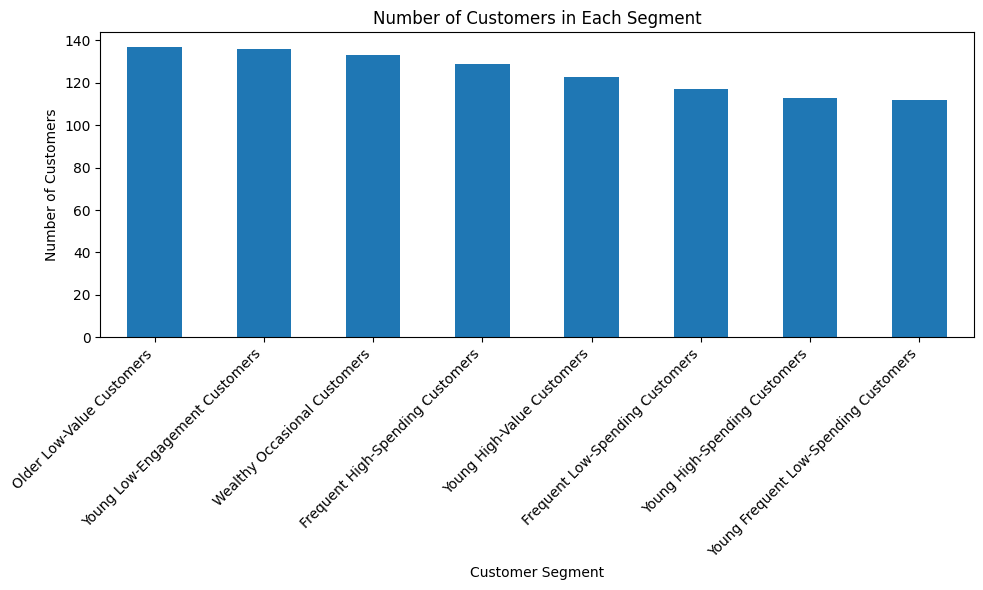

In [21]:
plt.figure(figsize=(10, 6))

segment_counts.plot(kind='bar')

plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Number of Customers in Each Segment')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

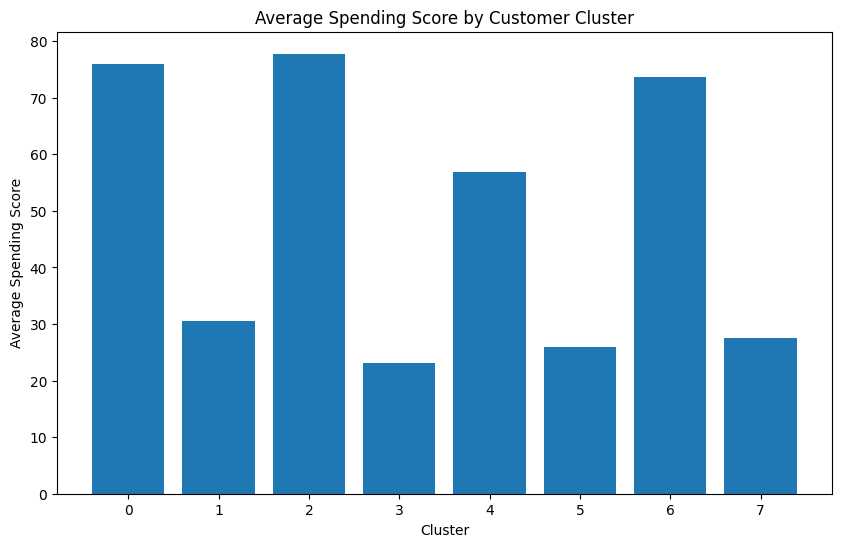

In [22]:
plt.figure(figsize=(10, 6))

plt.bar(
    cluster_summary.index.astype(str),
    cluster_summary['spending_score']
)

plt.xlabel('Cluster')
plt.ylabel('Average Spending Score')
plt.title('Average Spending Score by Customer Cluster')

plt.show()

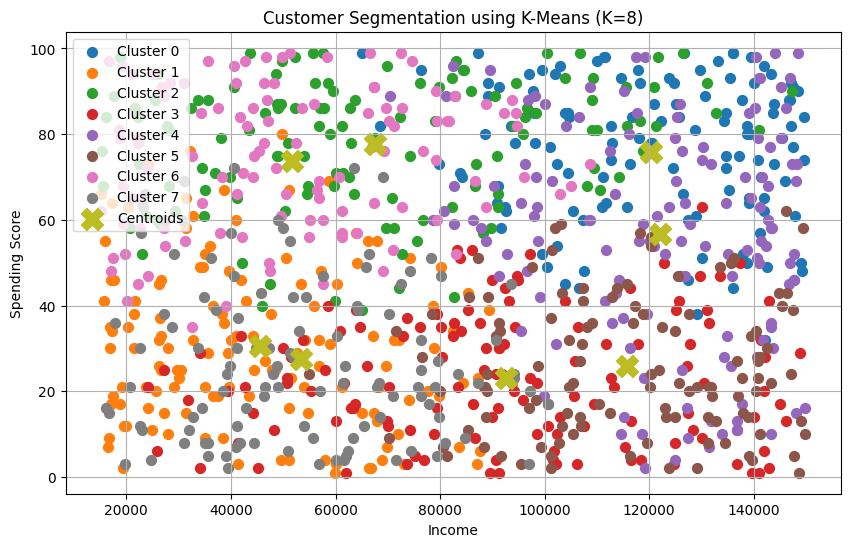

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Create K-Means model with the selected K = 8
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)

# Fit model and assign clusters
labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to the dataset
df['Cluster'] = labels

# Create 2D visualization
plt.figure(figsize=(10, 6))

for cluster in np.unique(labels):
    cluster_data = df[df['Cluster'] == cluster]
    
    plt.scatter(
        cluster_data['income'],
        cluster_data['spending_score'],
        s=50,
        label=f'Cluster {cluster}'
    )

# Convert cluster centers back to original scale
centers = scaler.inverse_transform(kmeans.cluster_centers_)

# Plot centroids
plt.scatter(
    centers[:, 1],
    centers[:, 2],
    marker='X',
    s=250,
    label='Centroids'
)

plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation using K-Means (K=8)')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
cluster_analysis = df.groupby('Cluster').agg(
    Customers=('customer_id', 'count'),
    Avg_Age=('age', 'mean'),
    Avg_Income=('income', 'mean'),
    Avg_Spending_Score=('spending_score', 'mean'),
    Avg_Visits_Per_Month=('visits_per_month', 'mean')
)

cluster_analysis = cluster_analysis.round(2)

cluster_analysis

,Customers,Avg_Age,Avg_Income,Avg_Spending_Score,Avg_Visits_Per_Month
Cluster,,,,,
0,123,30.61,120429.11,75.93,12.29
1,137,57.91,45483.07,30.50,7.16
2,129,55.57,67509.46,77.80,14.67
3,136,32.31,92638.14,23.07,5.59
4,133,56.44,122099.80,56.81,5.07
5,117,48.94,115734.60,25.85,15.34
6,113,31.88,51642.83,73.75,6.44
7,112,33.25,53492.23,27.46,15.57


<Figure size 1200x600 with 0 Axes>

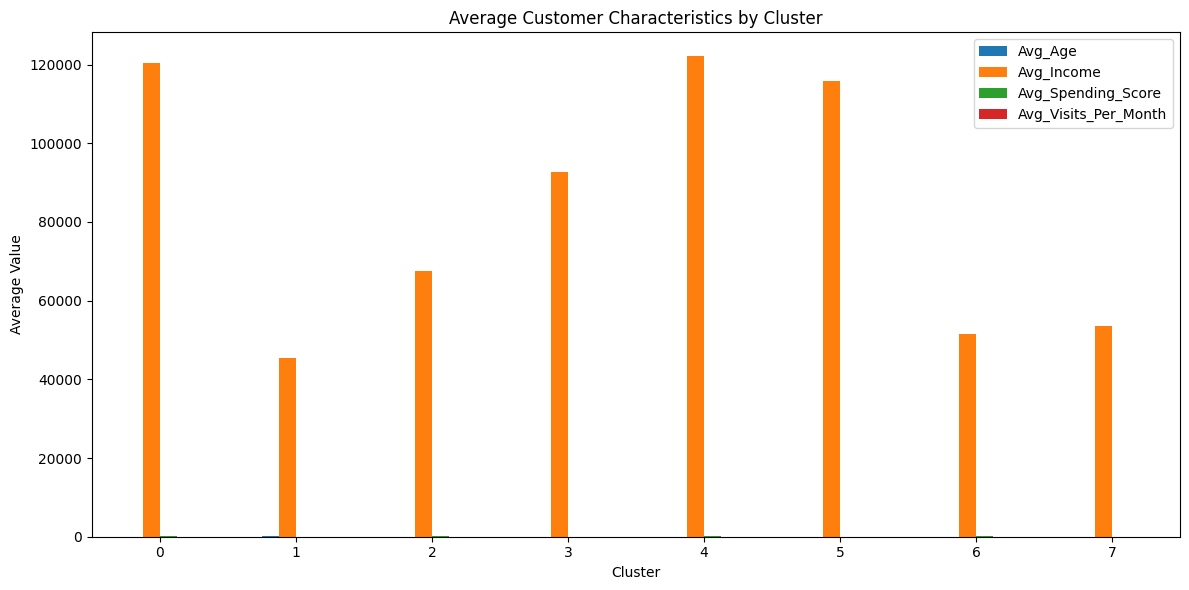

In [26]:
plt.figure(figsize=(12, 6))

cluster_analysis[['Avg_Age', 'Avg_Income',
                  'Avg_Spending_Score',
                  'Avg_Visits_Per_Month']].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Average Customer Characteristics by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()

plt.show()

In [27]:
cluster_analysis = df.groupby('Cluster').agg(
    Customers=('customer_id', 'count'),
    Avg_Age=('age', 'mean'),
    Avg_Income=('income', 'mean'),
    Avg_Spending_Score=('spending_score', 'mean'),
    Avg_Visits_Per_Month=('visits_per_month', 'mean')
)

cluster_analysis.round(2)

,Customers,Avg_Age,Avg_Income,Avg_Spending_Score,Avg_Visits_Per_Month
Cluster,,,,,
0,123,30.61,120429.11,75.93,12.29
1,137,57.91,45483.07,30.50,7.16
2,129,55.57,67509.46,77.80,14.67
3,136,32.31,92638.14,23.07,5.59
4,133,56.44,122099.80,56.81,5.07
5,117,48.94,115734.60,25.85,15.34
6,113,31.88,51642.83,73.75,6.44
7,112,33.25,53492.23,27.46,15.57


# Hierarchial Clustering

In [29]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

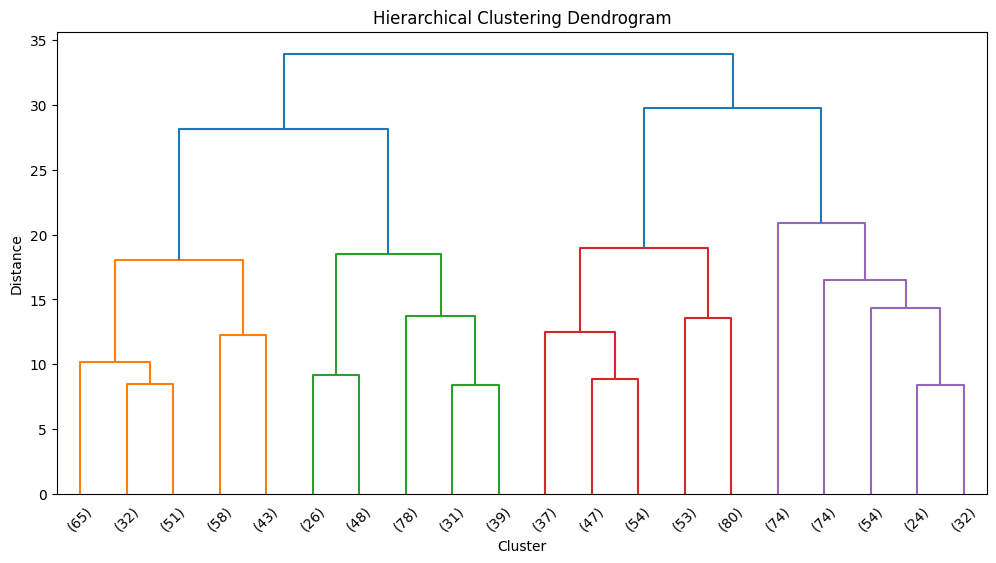

In [30]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=45,
    leaf_font_size=10
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster')
plt.ylabel('Distance')

plt.show()

In [32]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=8,
    linkage='ward'
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

df['Hierarchical_Cluster'] = hierarchical_labels

df.head()

,customer_id,age,income,spending_score,visits_per_month,Cluster,Segment,Hierarchical_Cluster
0,CUST1000,56,120186,55,9,4,Wealthy Occasional Customers,0
1,CUST1001,69,49674,80,1,1,Older Low-Value Customers,0
2,CUST1002,46,61271,62,8,6,Young High-Spending Customers,1
3,CUST1003,32,88688,30,6,3,Young Low-Engagement Customers,7
4,CUST1004,60,126076,55,6,4,Wealthy Occasional Customers,0


In [33]:
hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print("Hierarchical Clustering Silhouette Score:",
      round(hierarchical_silhouette, 4))

Hierarchical Clustering Silhouette Score: 0.1364


In [34]:
df['Hierarchical_Cluster'].value_counts().sort_index()

Hierarchical_Cluster
0    184
1    148
2    138
3    133
4     74
5    101
6     74
7    148
Name: count, dtype: int64

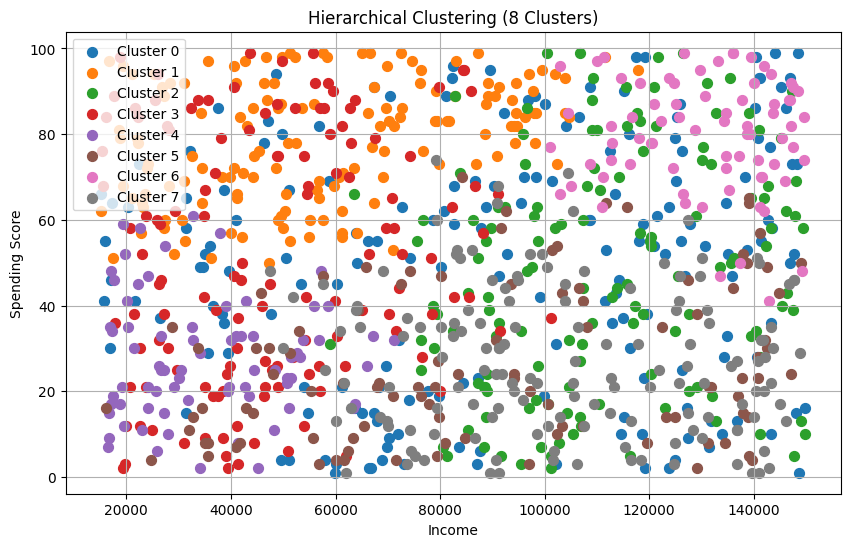

In [35]:
plt.figure(figsize=(10, 6))

for cluster in sorted(df['Hierarchical_Cluster'].unique()):
    cluster_data = df[df['Hierarchical_Cluster'] == cluster]

    plt.scatter(
        cluster_data['income'],
        cluster_data['spending_score'],
        s=50,
        label=f'Cluster {cluster}'
    )

plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.title('Hierarchical Clustering (8 Clusters)')
plt.legend()
plt.grid(True)

plt.show()

# DBSCAN clustering

In [37]:
from sklearn.cluster import DBSCAN

In [38]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

In [39]:
print("DBSCAN clusters:", sorted(df['DBSCAN_Cluster'].unique()))

DBSCAN clusters: [-1, 0, 1]


In [40]:
dbscan_counts = df['DBSCAN_Cluster'].value_counts().sort_index()

dbscan_counts

DBSCAN_Cluster
-1     55
 0    942
 1      3
Name: count, dtype: int64

In [41]:
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

if n_clusters >= 2:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
    print("DBSCAN Silhouette Score:",
          round(dbscan_silhouette, 4))
else:
    print("Silhouette Score cannot be calculated because DBSCAN found fewer than 2 clusters.")

DBSCAN Silhouette Score: 0.0282


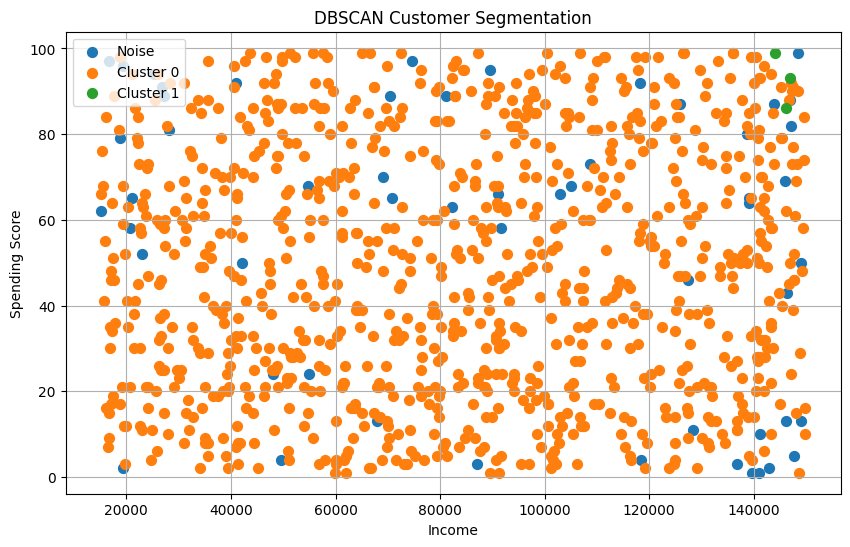

In [42]:
plt.figure(figsize=(10, 6))

for cluster in sorted(df['DBSCAN_Cluster'].unique()):

    cluster_data = df[df['DBSCAN_Cluster'] == cluster]

    if cluster == -1:
        label = 'Noise'
    else:
        label = f'Cluster {cluster}'

    plt.scatter(
        cluster_data['income'],
        cluster_data['spending_score'],
        s=50,
        label=label
    )

plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.title('DBSCAN Customer Segmentation')
plt.legend()
plt.grid(True)

plt.show()

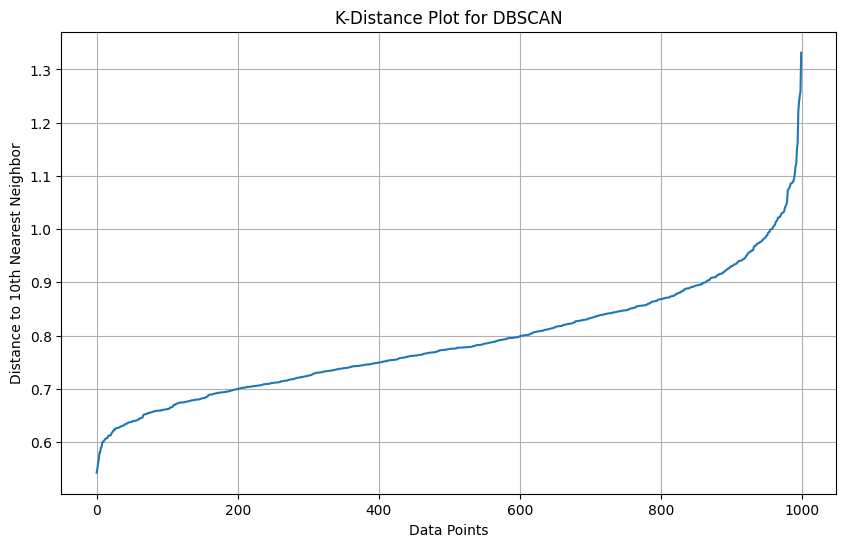

In [43]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Use min_samples = 10
min_samples = 10

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

# Take the distance to the 10th nearest neighbor
k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(10, 6))

plt.plot(k_distances)

plt.xlabel('Data Points')
plt.ylabel('Distance to 10th Nearest Neighbor')
plt.title('K-Distance Plot for DBSCAN')

plt.grid(True)
plt.show()

In [52]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd


In [46]:
eps_values = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

dbscan_results = []

for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=10
    )

    labels = model.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    if n_clusters >= 2:
        score = silhouette_score(X_scaled, labels)
    else:
        score = np.nan

    dbscan_results.append({
        'eps': eps,
        'clusters': n_clusters,
        'noise_points': n_noise,
        'silhouette_score': score
    })

dbscan_results = pd.DataFrame(dbscan_results)

dbscan_results.round(4)

,eps,clusters,noise_points,silhouette_score
0,0.50,0,1000,NaN
1,0.55,2,980,-0.2409
2,0.60,5,934,-0.3071
3,0.65,13,704,-0.2501
4,0.70,12,347,-0.3202
5,0.75,2,156,-0.0326
6,0.80,2,55,0.0282
7,0.85,1,11,NaN
8,0.90,1,3,NaN


In [47]:
dbscan = DBSCAN(
    eps=0.80,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

In [48]:
print("Number of clusters:",
      len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))

print("Number of noise points:",
      list(dbscan_labels).count(-1))

print("Silhouette Score:",
      round(silhouette_score(X_scaled, dbscan_labels), 4))

Number of clusters: 2
Number of noise points: 55
Silhouette Score: 0.0282


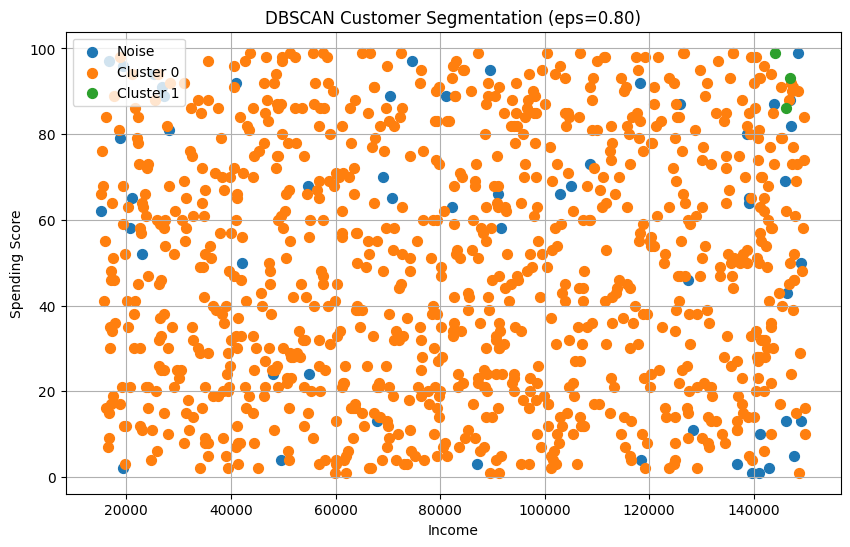

In [49]:
plt.figure(figsize=(10, 6))

for cluster in sorted(df['DBSCAN_Cluster'].unique()):

    cluster_data = df[df['DBSCAN_Cluster'] == cluster]

    if cluster == -1:
        label = 'Noise'
    else:
        label = f'Cluster {cluster}'

    plt.scatter(
        cluster_data['income'],
        cluster_data['spending_score'],
        s=50,
        label=label
    )

plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.title('DBSCAN Customer Segmentation (eps=0.80)')
plt.legend()
plt.grid(True)

plt.show()

# Comparison

In [50]:
comparison = pd.DataFrame({
    'Method': [
        'K-Means',
        'Hierarchical',
        'DBSCAN'
    ],
    'Number_of_Clusters': [
        8,
        8,
        2
    ],
    'Silhouette_Score': [
        silhouette_score(X_scaled, df['Cluster']),
        hierarchical_silhouette,
        dbscan_silhouette
    ]
})

comparison['Silhouette_Score'] = comparison['Silhouette_Score'].round(4)

comparison

,Method,Number_of_Clusters,Silhouette_Score
0,K-Means,8,0.2229
1,Hierarchical,8,0.1364
2,DBSCAN,2,0.0282


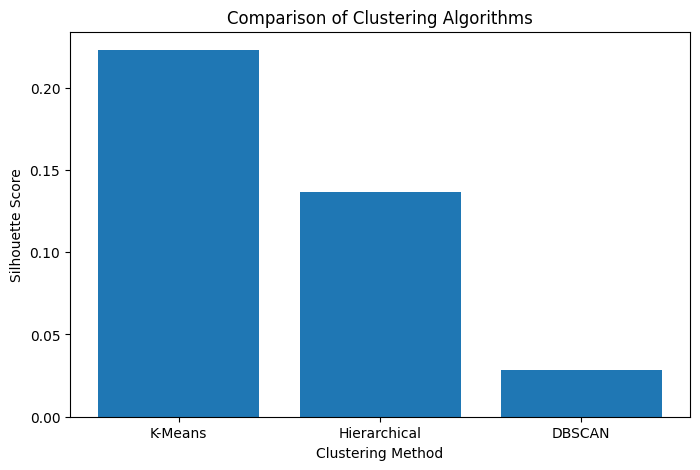

In [51]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison['Method'],
    comparison['Silhouette_Score']
)

plt.xlabel('Clustering Method')
plt.ylabel('Silhouette Score')
plt.title('Comparison of Clustering Algorithms')

plt.show()

# Conclusion

After testing all three clustering methods, K-Means gave the best result for our customer dataset. It achieved the highest silhouette score of 0.2230, compared with 0.1364 for Hierarchical Clustering and 0.0282 for DBSCAN.

This means that, among the three methods we tested, K-Means was able to create the most clearly separated customer groups.

Hierarchical Clustering also produced reasonable groups, but its silhouette score was lower than K-Means. DBSCAN performed the weakest in this case. It identified only two main clusters and 55 customers as noise, which suggests that DBSCAN was not well suited to the structure of this particular dataset.

Therefore, K-Means with 8 clusters will be used as the main model for our customer segmentation analysis. These eight groups can then be examined based on their age, income, spending score, and number of monthly visits to understand the different types of customers and develop suitable business strategies for each group.